In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("superstore_sales.xlsx")

In [98]:
df.head(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,month_yr,prod_sales
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,2011,2011-01,NaN
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,2011,2011-01,NaN


In [7]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

In [11]:
df.describe(include='number')

,sales,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.641740,26.375818,2012.777208
std,487.565361,2.278766,0.212280,174.424113,57.296810,1.098931
min,0.444000,1.000000,0.000000,-6599.978000,0.002000,2011.000000
25%,30.758625,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,85.053000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,251.053200,5.000000,0.200000,36.810000,24.450000,2014.000000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000,2014.000000


## OBJECTIVE
- What is the overall sales trend?

- Which are the Top 10 products by sales?

- Which are the Most Selling Products?

- Which is the most preferred Ship Mode?

- Which are the Most Profitable Category and Sub-Category?


## - What is the overall sales trend?

In [ ]:
#MIN DATE
df['order_date'].min()

Timestamp('2011-01-01 00:00:00')

In [ ]:
#MAX DATE
df['order_date'].max()

Timestamp('2014-12-31 00:00:00')

In [ ]:
#CONVERTING OUR DATA IN MONTH - YEAR FORMAT
df['month_yr']=df['order_date'].apply(lambda x: x.strftime("%Y-%m"))
df['month_yr']

0        2011-01
1        2011-01
2        2011-01
3        2011-01
4        2011-01
          ...   
51285    2014-12
51286    2014-12
51287    2014-12
51288    2014-12
51289    2014-12
Name: month_yr, Length: 51290, dtype: object

In [ ]:
# GROUPING MONTH YEAR ACCORDING TO TOTAL SALES
trend=df.groupby('month_yr')['sales'].sum().reset_index()
trend

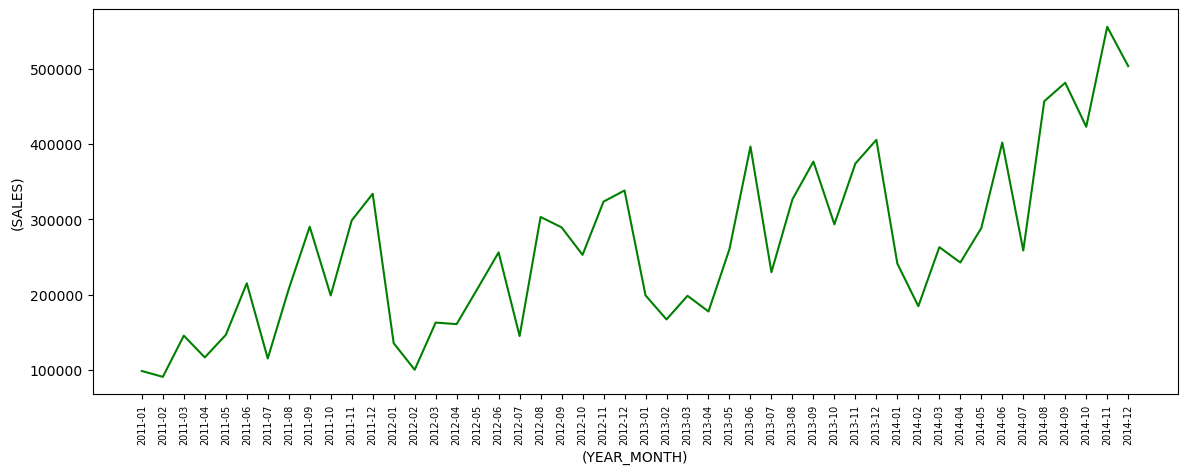

In [ ]:
# VISUALIZATION
plt.figure(figsize=(14,5))
plt.plot(trend['month_yr'],trend['sales'],color='green')
plt.xticks(rotation='vertical',size=7)
plt.xlabel('(YEAR_MONTH)')
plt.ylabel('(SALES)')
plt.show()

- Which are the Top 10 products by sales?

In [49]:
prod_sales = pd.DataFrame(df.groupby('product_name')['sales'].sum())

In [50]:
prod_sales = prod_sales.sort_values('sales',ascending=False)

In [53]:
prod_sales[:10]

,sales
product_name,
"Apple Smart Phone, Full Size",86935.7786
"Cisco Smart Phone, Full Size",76441.5306
"Motorola Smart Phone, Full Size",73156.3030
"Nokia Smart Phone, Full Size",71904.5555
Canon imageCLASS 2200 Advanced Copier,61599.8240
"Hon Executive Leather Armchair, Adjustable",58193.4841
"Office Star Executive Leather Armchair, Adjustable",50661.6840
"Harbour Creations Executive Leather Armchair, Adjustable",50121.5160
"Samsung Smart Phone, Cordless",48653.4600


## - Which are the Most Selling Products?

 most selling products means product with most selling quantities

In [67]:
most_sell=pd.DataFrame(df.groupby('product_name')['quantity'].sum())

In [68]:
most_sell

,quantity
product_name,
"""While you Were Out"" Message Book, One Form per Page",8
"#10 Gummed Flap White Envelopes, 100/Box",11
#10 Self-Seal White Envelopes,10
"#10 White Business Envelopes,4 1/8 x 9 1/2",32
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",37
...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",24
iOttie HLCRIO102 Car Mount,12
iOttie XL Car Mount,14


In [69]:
most_sell=most_sell.sort_values('quantity',ascending=False)

In [70]:
most_sell[:10]

,quantity
product_name,
Staples,876
"Cardinal Index Tab, Clear",337
"Eldon File Cart, Single Width",321
"Rogers File Cart, Single Width",262
"Sanford Pencil Sharpener, Water Color",259
"Stockwell Paper Clips, Assorted Sizes",253
"Avery Index Tab, Clear",252
"Ibico Index Tab, Clear",251
"Smead File Cart, Single Width",250


## - Which is the most preferred Ship Mode?

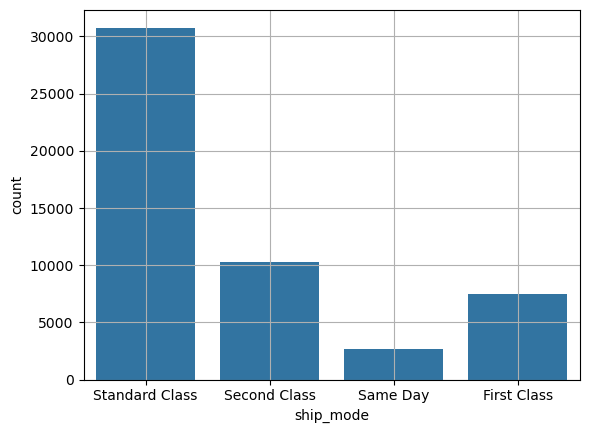

In [79]:
sns.countplot(x='ship_mode',data=df)
plt.grid(True)

## - Which are the Most Profitable Category and Sub-Category?

In [82]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'month_yr', 'prod_sales'],
      dtype='object')

In [91]:
cat_data=pd.DataFrame(df.groupby(['category','sub_category'])['profit'].sum()).reset_index()

In [92]:
cat_data=cat_data.sort_values(['profit'],ascending=False)

In [93]:
cat_data

,category,sub_category,profit
14,Technology,Copiers,258567.54818
16,Technology,Phones,216717.00580
0,Furniture,Bookcases,161924.41950
1,Furniture,Chairs,141973.79750
4,Office Supplies,Appliances,141680.58940
13,Technology,Accessories,129626.30620
11,Office Supplies,Storage,108461.48980
6,Office Supplies,Binders,72449.84600
10,Office Supplies,Paper,59207.68270
15,Technology,Machines,58867.87300


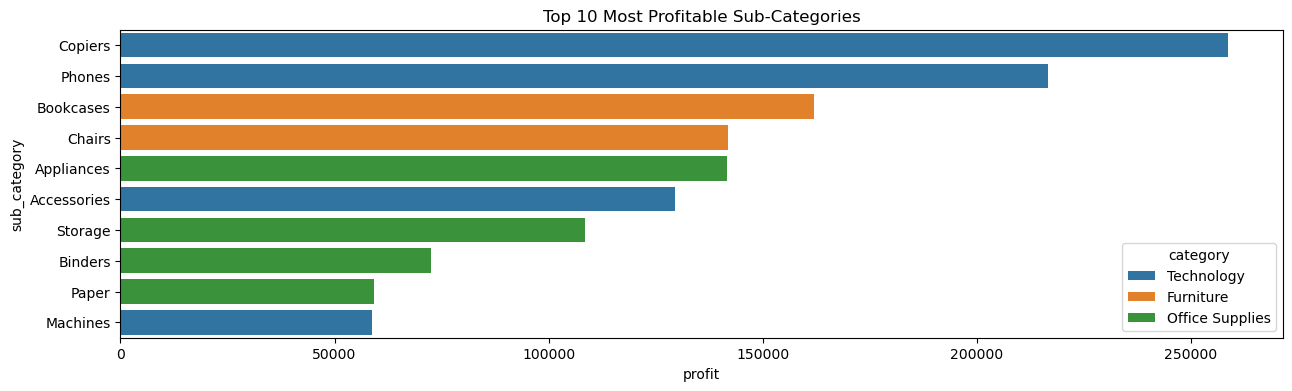

In [103]:
plt.figure(figsize=(15,4))

sns.barplot(
    data=cat_data.head(10),
    x='profit',
    y='sub_category',
    hue='category'
)

plt.title('Top 10 Most Profitable Sub-Categories')
plt.show()